# EcoTTA Adaptation on APTOS2019 (VisionFM)
EcoTTA: frozen encoder + per-partition meta networks with self-distilled regularization.

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/ecotta/aptos_visionfm.yaml')

print('Dataset:', config.target_dataset.name)
print('Method:', config.ctta.method)
print('Mode: every-batch (no shift detection gate)')
print('Output:', config.output_dir)

# VisionFM weights come from Google Drive; no HF token needed.
if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Dataset: aptos2019
Method: ecotta
Mode: every-batch (no shift detection gate)
Output: ./outputs/ecotta/aptos_visionfm/
No HF token needed (VisionFM / Google Drive)


In [4]:
from src.evaluation.runner import CTTARunner

runner = CTTARunner(config)
results = runner.run()

2026-08-21 09:34:10,719 - src.evaluation.runner.single - INFO - Starting CTTA adaptation on dataset: aptos2019
2026-08-21 09:34:10,844 - src.models.visionfm_download - INFO - Downloading VisionFM Fundus weights from Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4
From (redirected): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4&confirm=t&uuid=1e345625-33a4-4902-803f-b00b9b81b4f2
To: /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
100%|██████████| 1.51G/1.51G [00:12<00:00, 118MB/s] 

2026-08-21 09:34:25,524 - src.models.visionfm_download - INFO - VisionFM Fundus weights downloaded to ./cache/visionfm/VFM_Fundus_weights.pth


2026-08-21 09:34:26,726 - src.models.visionfm - INFO - Loading VisionFM checkpoint from /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
2026-08-21 09:34:27,701 - src.models.visionfm - INFO - Extracted state_dict from 'teacher' key
2026-08-21 09:34:27,702 - src.models.visionfm - INFO - Stripped 'backbone.' prefix from 160 state dict keys
2026-08-21 09:34:27,773 - src.models.visionfm - INFO - VisionFM checkpoint cached in CPU RAM
2026-08-21 09:34:27,818 - src.models.visionfm - INFO - Frozen first 8 of 12 transformer blocks
2026-08-21 09:34:27,819 - src.models.visionfm - INFO - Feature normalization ENABLED in forward()
2026-08-21 09:34:28,200 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-08-21 09:37:27,967 - src.evaluation.runner.base - INFO - Prototype weights scaled by T=50.0
2026-08-21 09:37:27,971 - src.evaluation.runner.base - INFO - Prototype classifier initialized from 2930 training samples (5 classes, 3072-dim features, T=50.0)
2

Adapting to aptos2019:   0%|          | 0/23 [00:00<?, ?it/s]

...

Adapting to aptos2019:  96%|█████████▌| 22/23 [00:28<00:01,  1.22s/it, acc=0.8750, adaptations=22]

2026-08-21 09:48:22,277 - src.evaluation.runner.single - INFO -   Adapt step 22: loss=0.0782, entropy=0.4688, ent_loss=0.0177, reg=0.1212, conf_samples=3


Adapting to aptos2019: 100%|██████████| 23/23 [00:29<00:00,  1.30s/it, acc=0.7143, adaptations=23]

2026-08-21 09:48:22,501 - src.evaluation.runner.single - INFO - Evaluating after adaptation on aptos2019


2026-08-21 09:48:45,629 - src.evaluation.runner.single - INFO - Post-adaptation QWK: 0.8731
2026-08-21 09:48:45,631 - src.evaluation.runner.single - INFO - Adaptations: 23/23
2026-08-21 09:48:45,689 - src.evaluation.runner.base - INFO - Results saved to outputs/ecotta/aptos_visionfm/ctta_results.json


In [5]:
print('=== Results ===')
print(f'Baseline QWK:        {results["baseline_metrics"]["qwk"]:.4f}')
print(f'Baseline Accuracy:   {results["baseline_metrics"]["overall_accuracy"]*100:.2f}%')
print(f'Post-adapt QWK:      {results["final_metrics"]["qwk"]:.4f}')
print(f'Post-adapt Accuracy: {results["final_metrics"]["overall_accuracy"]*100:.2f}%')
dr = results['domain_result']
print(f'Adaptations:          {dr["num_adaptations"]}/{dr["total_batches"]}')
print(f'Adaptation rate:      {results.get("adaptation_rate", 0)*100:.2f}%')

gap = results['final_metrics']['qwk'] - results['baseline_metrics']['qwk']
print(f'QWK change:           {gap:+.4f}')
acc_gap = results['final_metrics']['overall_accuracy'] - results['baseline_metrics']['overall_accuracy']
print(f'Accuracy change:      {acc_gap*100:+.2f}%')

=== Results ===
Baseline QWK:        0.7556
Baseline Accuracy:   71.04%
Post-adapt QWK:      0.8731
Post-adapt Accuracy: 81.42%
Adaptations:          23/23
Adaptation rate:      100.00%
QWK change:           +0.1174
Accuracy change:      +10.38%


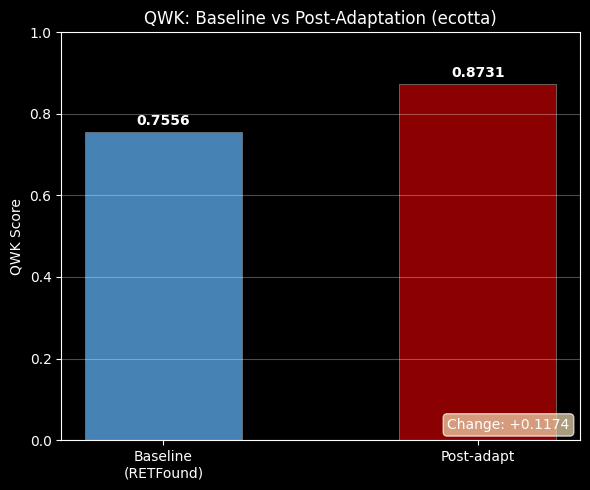

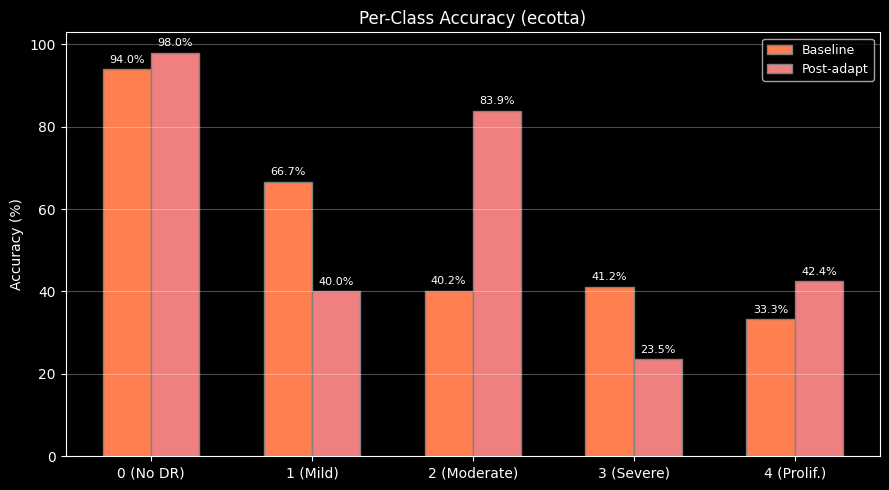

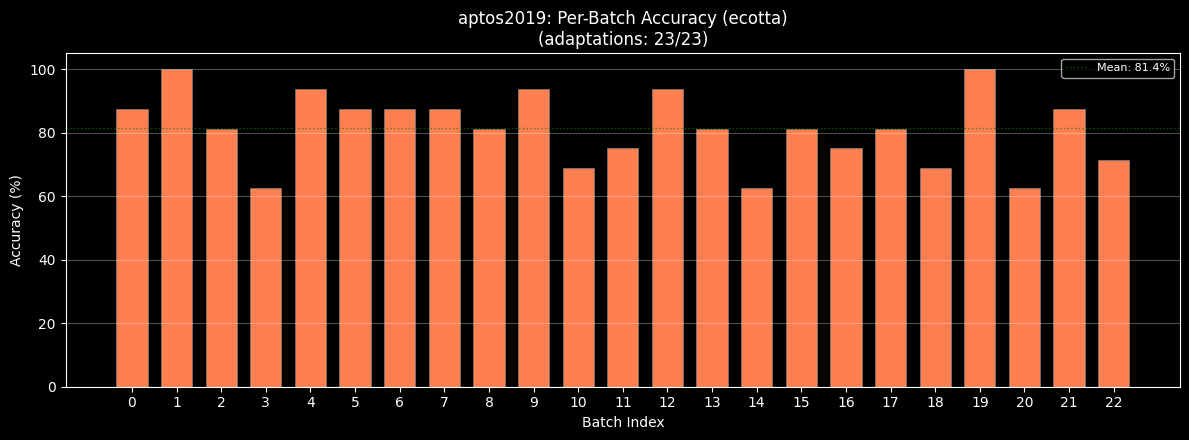

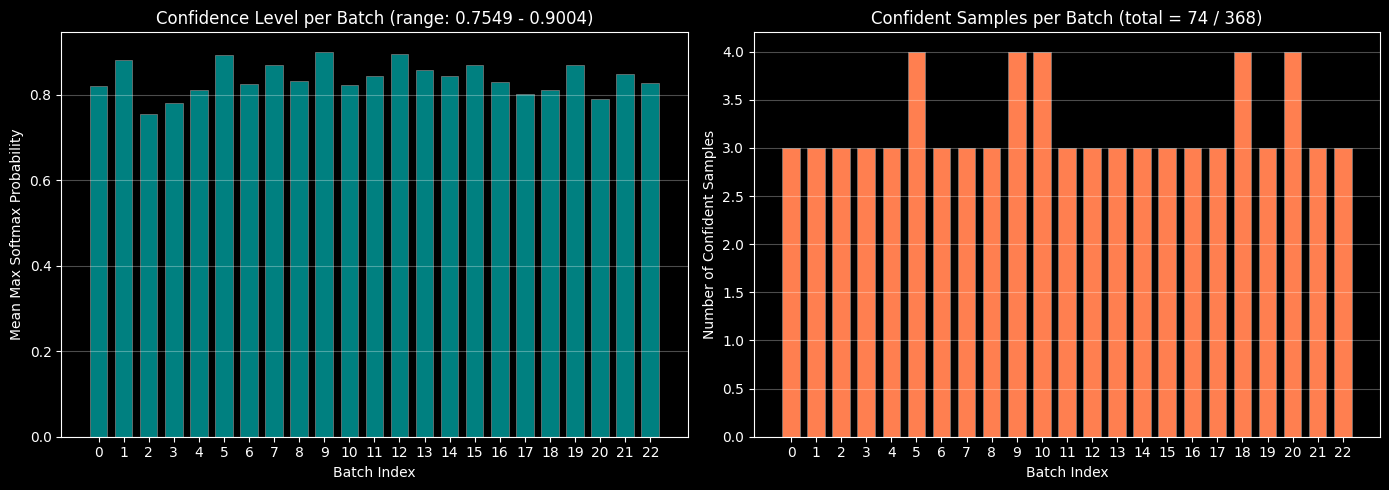

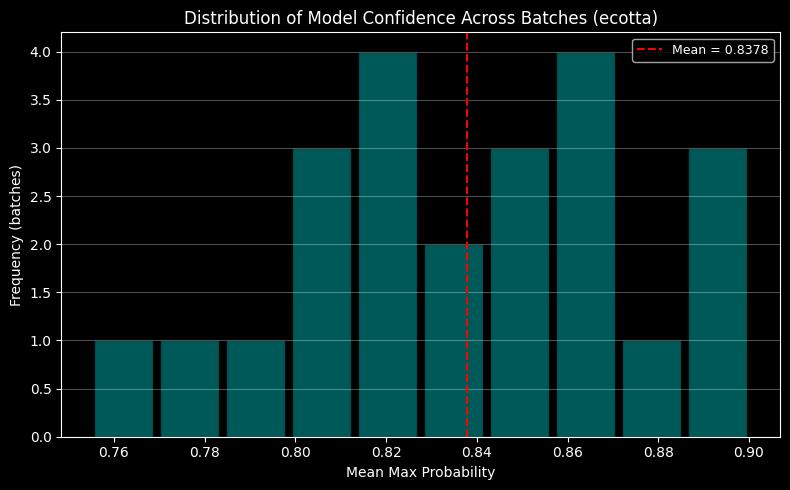

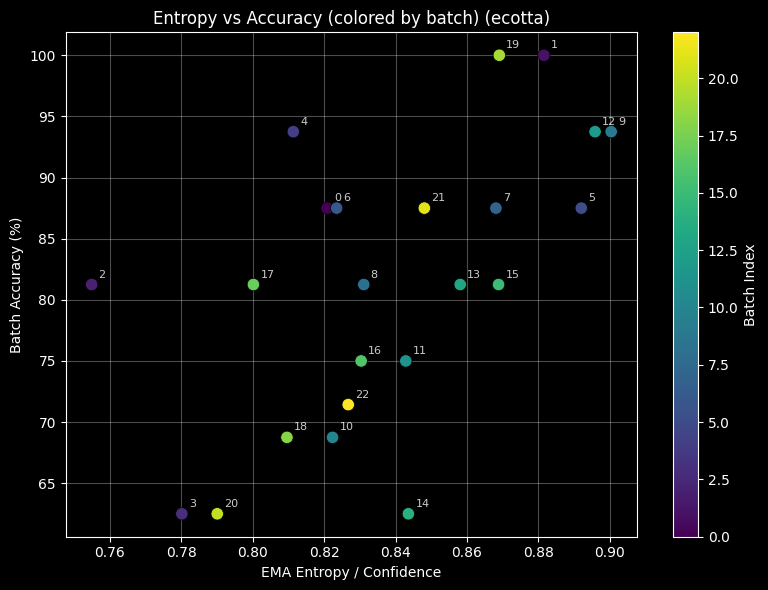

===================== CTTA Results (ecotta) =====================
Baseline QWK:       0.7556
Post-adapt QWK:     0.8731
Adaptations:        23/23
Adaptation rate:    100.00%
QWK change:         +0.1174
Mean batch acc:     81.4%


In [6]:
from src.viz import (
    get_domain_data, plot_qwk_bar, plot_per_batch_accuracy,
    plot_adaptation_metrics, plot_confidence_distribution,
    plot_entropy_vs_accuracy, print_summary_table, plot_per_class_accuracy as plot_pca,
)

import json
from pathlib import Path

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

with open(Path(config.output_dir) / 'ctta_results.json') as f:
    results = json.load(f)

dr = results['domain_result']
method = results.get("method", "")

plot_qwk_bar(results, plots_dir, method_name=method)
plot_pca(results, dr, plots_dir, method_name=method)
plot_per_batch_accuracy(dr, None, plots_dir, method_name=method)
plot_adaptation_metrics(dr['adaptation_steps'], plots_dir)
plot_confidence_distribution(dr['adaptation_steps'], plots_dir, method_name=method)
plot_entropy_vs_accuracy(dr['adaptation_steps'], dr['batch_metrics'], plots_dir, method_name=method)
print_summary_table(results, method_name=method)